In [1]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import re

In [2]:
# Movie Reviews
reviews = [
    "Amazing movie with great acting",
    "Worst movie ever",
    "Good story and excellent music",
    "Very boring film",
    "Average movie"
]

df = pd.DataFrame(reviews, columns=["Review"])

In [3]:
# Text Cleaning
def clean_text(text):
    return re.sub(r"[^a-zA-Z ]", "", text.lower())

df["Cleaned"] = df["Review"].apply(clean_text)

In [4]:
# Sentiment Analysis
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(get_sentiment)

print(df)

                            Review                          Cleaned Sentiment
0  Amazing movie with great acting  amazing movie with great acting  Positive
1                 Worst movie ever                 worst movie ever  Negative
2   Good story and excellent music   good story and excellent music  Positive
3                 Very boring film                 very boring film  Negative
4                    Average movie                    average movie  Negative


In [5]:
# Trending Words
words = " ".join(df["Cleaned"]).split()

print("\nTrending Words")
print(pd.Series(words).value_counts().head(5))


Trending Words
movie      3
amazing    1
with       1
great      1
acting     1
Name: count, dtype: int64


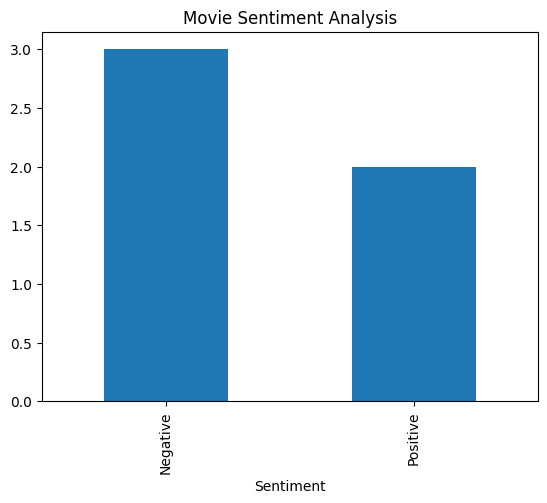

In [6]:
# Visualization
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Movie Sentiment Analysis")
plt.show()